<h1>Simple Linear Regression using Scikit-learn and Gradient Descent on Loan Default Dataset</h1>

<h2>Part-A Simple Linear Regression using Scikit-learn</h2>
<h3>Import Required Libraries</h3>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

<h3>1. Import Data Set</h3>

In [3]:
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


<h3>2. Display Dataset Information & Statistical Summary</h3>

In [4]:
print(df.info())
print("==================================================")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

<h3>3. Fit model using sklearn</h3>

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib

# Select Feature (Income) and Target (LoanAmount)
X = df[['Income']]
y = df['LoanAmount']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

#Make File PKL
model_fileName = "loan_default.pkl"
joblib.dump(model,model_fileName)
print("Model File Successfully make")

Model File Successfully make


<h3>4. Display Coefficient and Intercept</h3>

In [6]:
# Equation Parameters
print("Coefficient (Slope):", model.coef_)
print("Intercept:", model.intercept_)

Coefficient (Slope): [-0.00099862]
Intercept: 127665.38029039632


<h3>5. Predict Values & Calculate Mean Squared Error</h3>

In [7]:
y_pred = model.predict(X_test)
print("Sample Predictions:", y_pred[:5])

print("=====================================")

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

print("=====================================")

sample_income = 85000
print(f"For New Income = ${sample_income:,}")
new_data = [[sample_income]]
prediction = model.predict(new_data)
print("Predicted Loan Amount: $", round(prediction[0], 2))

print("=====================================")

Sample Predictions: [127552.87971856 127573.93762545 127587.31913786 127602.43425517
 127635.75621832]
Mean Squared Error (MSE): 5022054261.812393
For New Income = $85,000
Predicted Loan Amount: $ 127580.5


<h3>6. Compare Actual vs Predicted</h3>

In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

   Actual      Predicted
0   92393  127552.879719
1  131575  127573.937625
2   75417  127587.319138
3   10804  127602.434255
4   21182  127635.756218
5  187008  127567.005203
6  159105  127616.037461
7  173967  127547.925563
8   41189  127571.037632
9  151275  127570.179817


<h3>7. Plot the Regression Line</h3>

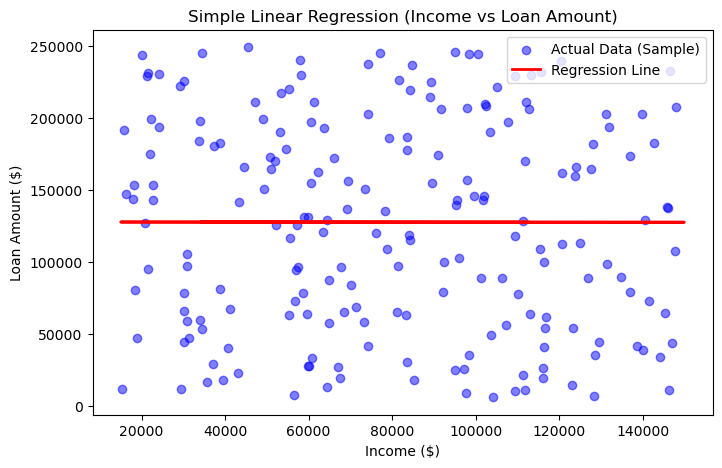

In [9]:
plt.figure(figsize=(8,5))
# Plot sample points for clarity on large dataset
sample_indices = np.random.choice(len(X_test), 200, replace=False)
plt.scatter(X_test.iloc[sample_indices], y_test.iloc[sample_indices], color='blue', alpha=0.5, label='Actual Data (Sample)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Income ($)")
plt.ylabel("Loan Amount ($)")
plt.title("Simple Linear Regression (Income vs Loan Amount)")

plt.legend()
plt.show()

<h2>Part-B Implement Gradient Descent By Hand</h2>
<h3>1. Linear Regression using Gradient Descent</h3>

In [10]:
X = df['Income'].values.astype(float)
y = df['LoanAmount'].values.astype(float)
n = len(X)

# Feature Scaling (Standardization) for numerical stability in Gradient Descent
X_mean, X_std = np.mean(X), np.std(X)
y_mean, y_std = np.mean(y), np.std(y)

X_scaled = (X - X_mean) / X_std
y_scaled = (y - y_mean) / y_std

m = 0.0  # Initial slope guess
c = 0.0  # Initial intercept guess
lr = 0.01  # Learning rate
epochs = 1000  # Number of learning iterations

loss_history = []

for i in range(epochs):
    y_pred_scaled = m * X_scaled + c # Current scaled prediction
    
    error = y_pred_scaled - y_scaled # Predicted - Actual
    
    loss = (1/n) * np.sum(error**2)  # MSE (Mean-squared error)
    loss_history.append(loss)
    
    dm = (2/n) * np.sum(error * X_scaled) # Gradient wrt slope
    dc = (2/n) * np.sum(error)            # Gradient wrt intercept
    
    m = m - lr * dm # Update slope
    c = c - lr * dc # Update intercept
    
    if i % 200 == 0:
        print(f'epoch {i}: loss={loss:.4f} m={m:.4f} c={c:.4f}')

# Convert m and c back to original (unscaled) parameters
m_unscaled = m * (y_std / X_std)
c_unscaled = (c * y_std + y_mean) - m_unscaled * X_mean

print('\nFinal Scaled parameters -> m:', m, ' c:', c)
print('Final Unscaled parameters -> Slope (m):', m_unscaled, ' Intercept (c):', c_unscaled)

epoch 0: loss=1.0000 m=-0.0000 c=0.0000
epoch 200: loss=1.0000 m=-0.0009 c=0.0000
epoch 400: loss=1.0000 m=-0.0009 c=0.0000
epoch 600: loss=1.0000 m=-0.0009 c=0.0000
epoch 800: loss=1.0000 m=-0.0009 c=0.0000

Final Scaled parameters -> m: -0.0008653256544695103  c: 4.116855343023397e-17
Final Unscaled parameters -> Slope (m): -0.00157329412018136  Intercept (c): 127708.66118326229


epoch 200: loss=1.0000 m=-0.0009 c=0.0000


epoch 400: loss=1.0000 m=-0.0009 c=0.0000


epoch 600: loss=1.0000 m=-0.0009 c=0.0000


epoch 800: loss=1.0000 m=-0.0009 c=0.0000



Final Scaled parameters -> m: -0.0008653256544695103  c: 4.116855343023397e-17
Final Unscaled parameters -> Slope (m): -0.00157329412018136  Intercept (c): 127708.66118326229


In [11]:
print("Slope (m):", m_unscaled)
print("Intercept (c):", c_unscaled)

print(f"Regression Equation: LoanAmount = {m_unscaled:.6f} * Income + {c_unscaled:.2f}")

print("=======================================================================")

y_pred_unscaled = m_unscaled * X + c_unscaled
mse = np.mean((y - y_pred_unscaled) ** 2)

print("Mean Squared Error (MSE):", mse)

Slope (m): -0.00157329412018136
Intercept (c): 127708.66118326229
Regression Equation: LoanAmount = -0.001573 * Income + 127708.66
Mean Squared Error (MSE): 5018382235.638494


<h3>2. Plot the regression line</h3>

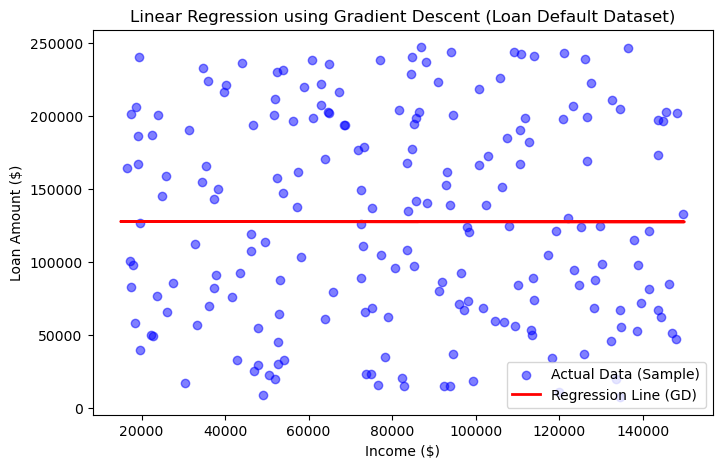

In [12]:
plt.figure(figsize=(8,5))

# Plot sample of 200 points for clear visual representation
sample_idx = np.random.choice(len(X), 200, replace=False)
plt.scatter(X[sample_idx], y[sample_idx], color='blue', alpha=0.5, label='Actual Data (Sample)')
plt.plot(X, y_pred_unscaled, color='red', linewidth=2, label='Regression Line (GD)')

plt.xlabel("Income ($)")
plt.ylabel("Loan Amount ($)")
plt.title("Linear Regression using Gradient Descent (Loan Default Dataset)")
plt.legend()
plt.show()

<h3>3. Loss VS Epoch</h3>

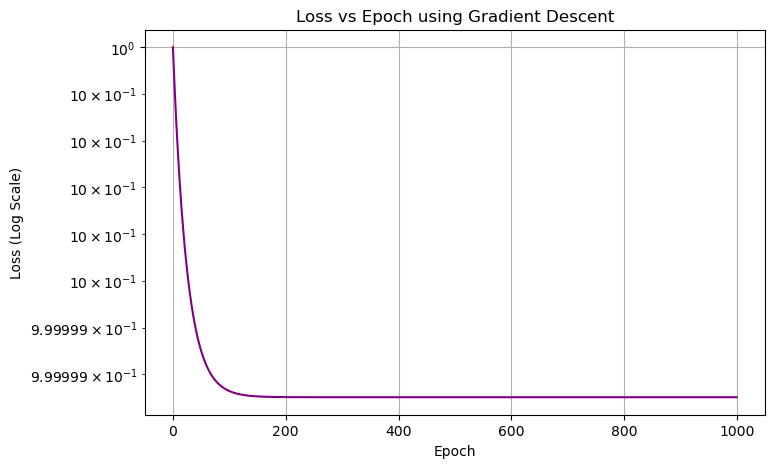

In [13]:
plt.figure(figsize=(8,5))

plt.plot(loss_history, color='purple')

plt.yscale('log')

plt.xlabel("Epoch")
plt.ylabel("Loss (Log Scale)")
plt.title("Loss vs Epoch using Gradient Descent")
plt.grid(True)

plt.show()

<h3>4. Predict a New Value</h3>

In [14]:
new_income = 85000

predicted_loanamount = m_unscaled * new_income + c_unscaled

print(f"For New Income = ${new_income:,}")
print("Predicted Loan Amount:", round(predicted_loanamount, 2))

For New Income = $85,000
Predicted Loan Amount: 127574.93
